# **prepration**

# 1-1.total

In [ ]:
!pip install arabic-reshaper
!pip install python-bidi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.9/292.9 kB 7.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from bidi.algorithm import get_display
from arabic_reshaper import reshape

In [ ]:
#inside_ad
data=pd.read_excel('/content/drive/MyDrive/thesis/final44.xlsx')
data=data.drop(columns=[3])
data2=data
data2=data2.drop(columns=['adv'])

In [ ]:
# outside_ad
df=pd.read_excel('/content/adv_out.xlsx')

In [ ]:
# additional data(total data)
data3=pd.read_excel('/content/drive/MyDrive/thesis/final.xlsx')

In [ ]:
data2['adv_out']=df['adv_out']

In [ ]:
data2['travel_time'] = pd.Series(dtype=int)

for i in data2.index:
    if data2.loc[i, 't_journey_duration '] >= 0 and data2.loc[i, 't_journey_duration'] < 5:
        data2.loc[i, 'travel_time'] = 1
    elif data2.loc[i, 't_journey_duration '] >= 5 and data2.loc[i,'t_journey_duration'] < 10:
        data2.loc[i, 'travel_time'] = 2
    elif data2.loc[i,'t_journey_duration '] >= 10 and data2.loc[i,'t_journey_duration '] < 20:
        data2.loc[i, 'travel_time'] = 3
    elif data2.loc[i,'t_journey_duration'] >= 20 and data2.loc[i, 't_journey_duration'] < 30:
        data2.loc[i, 'travel_time'] = 4
    elif data2.loc[i, 't_journey_duration'] >= 30 and data2.loc[i, 't_journey_duration '] < 40:
        data2.loc[i, 'travel_time'] = 5

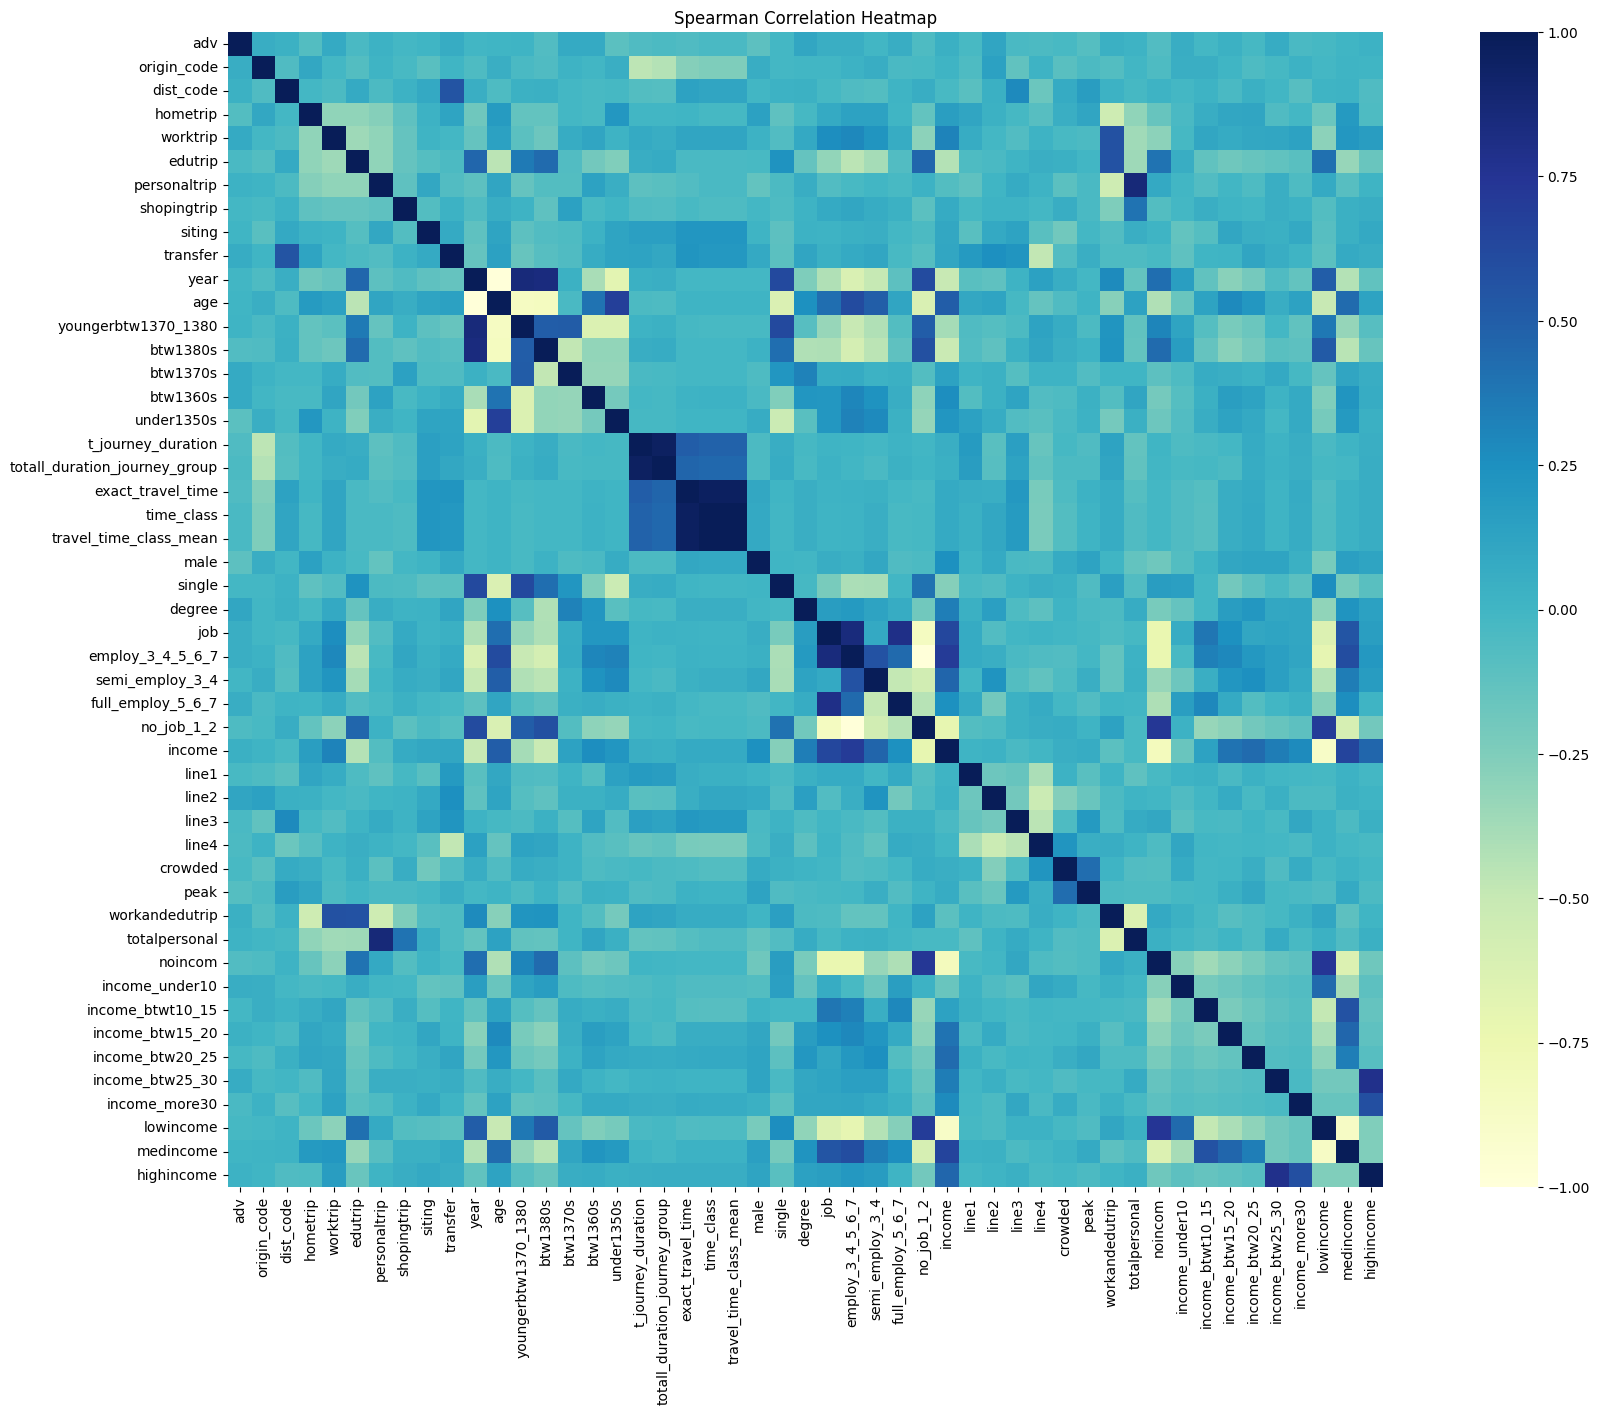

In [ ]:
# spearman correlation
plt.figure(figsize=(25, 15))
sns.heatmap(data.corr(method='spearman'), annot=False, cmap="YlGnBu", fmt='.2f', square=True)
plt.title('Spearman Correlation Heatmap')
plt.show()

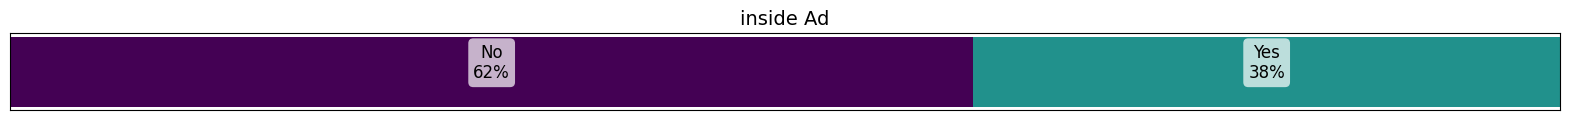

In [ ]:
import matplotlib.pyplot as plt

# Calculate counts, total, and proportions
counts = data['adv'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

# Create a figure with a specified size
plt.figure(figsize=(20, 1))

# Initialize cumulative sum and choose colors from the Viridis colormap
cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels = ['No', 'Yes']  # Labels corresponding to the counts

# Specify the desired font size
label_fontsize = 12

# Plot the bars and add text annotations
for i, (label, proportion) in enumerate(zip(labels, proportions)):
    cumulative += proportion
    plt.barh(0, proportion, left=cumulative - proportion, color=colors[i], label=label)

    # Correct text annotation line
    plt.text(cumulative - proportion / 2, 0.1,
             f'{label}\n{proportion:.0%}',  # Display label and proportion as a percentage
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)
plt.yticks([])

# Add a title and a legend
plt.title('inside Ad', fontsize=14)
# plt.legend(title='Adv Output', loc='upper right', fontsize=12)

# Display the plot
plt.show()

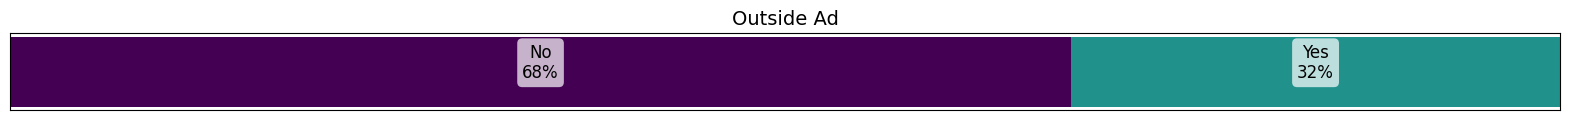

In [ ]:
import matplotlib.pyplot as plt

# Calculate counts, total, and proportions
counts = data2['adv_out'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

# Create a figure with a specified size
plt.figure(figsize=(20, 1))

# Initialize cumulative sum and choose colors from the Viridis colormap
cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels = ['No', 'Yes']  # Labels corresponding to the counts

# Specify the desired font size
label_fontsize = 12

# Plot the bars and add text annotations
for i, (label, proportion) in enumerate(zip(labels, proportions)):
    cumulative += proportion
    plt.barh(0, proportion, left=cumulative - proportion, color=colors[i], label=label)

    # Correct text annotation line
    plt.text(cumulative - proportion / 2, 0.1,
             f'{label}\n{proportion:.0%}',  # Display label and proportion as a percentage
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)
plt.yticks([])

# Add a title and a legend
plt.title('Outside Ad', fontsize=14)
# plt.legend(title='Adv Output', loc='upper right', fontsize=12)

# Display the plot
plt.show()

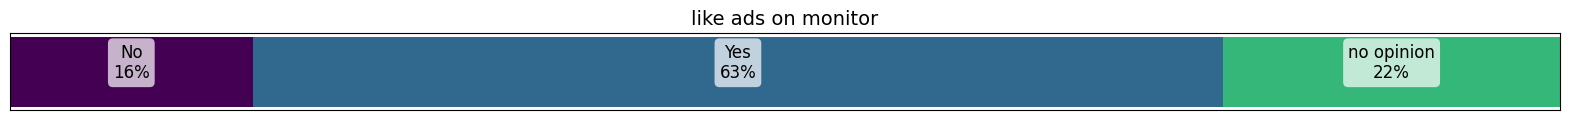

In [ ]:
import matplotlib.pyplot as plt

# Calculate counts, total, and proportions
counts = data3['3-1.'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

# Create a figure with a specified size
plt.figure(figsize=(20, 1))

# Initialize cumulative sum and choose colors from the Viridis colormap
cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels = ['No','Yes','no opinion']  # Labels corresponding to the counts

# Specify the desired font size
label_fontsize = 12

# Plot the bars and add text annotations
for i, (label, proportion) in enumerate(zip(labels, proportions)):
    cumulative += proportion
    plt.barh(0, proportion, left=cumulative - proportion, color=colors[i], label=label)

    # Correct text annotation line
    plt.text(cumulative - proportion / 2, 0.1,
             f'{label}\n{proportion:.0%}',  # Display label and proportion as a percentage
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)
plt.yticks([])

# Add a title and a legend
plt.title('like ads on monitor', fontsize=14)
# plt.legend(title='Adv Output', loc='upper right', fontsize=12)

# Display the plot
plt.show()

In [ ]:
def replace_character_in_column(df, column_name, char_to_replace, replacement_char):
    df[column_name] = df[column_name].apply(lambda x: x.replace(char_to_replace, replacement_char) if isinstance(x, str) and char_to_replace in x else x)
    return df

In [ ]:
 d=replace_character_in_column(data3, '3-2.', 'و', ',')
 data3['3-2.'] = d['3-2.'].fillna(data3['3-2.'])

In [ ]:
from collections import Counter

# Given list of lists
specified_column = data3['3-2.'].explode().tolist()
numbers = [int(num) if isinstance(num, (int, float)) else [int(x) for x in num.split(',')] for num in specified_column]
numbers = [num if isinstance(num, list) else [num] for num in numbers]

# Flatten the list of numbers
flattened_numbers = [x for sublist in numbers for x in sublist]

# Count the occurrences of each number
occurrences = dict(Counter(flattened_numbers))

# Print the count of each number
num=[]
co=[]
for number, count in occurrences.items():
    num.append(number)
    co.append(count)
n = pd.DataFrame(num, columns=['Numbers'])
c= pd.DataFrame(co, columns=['counts'])
num2 = pd.concat([n, c], axis=1)
num3 = num2.sort_values(by='Numbers').reset_index(drop=True)

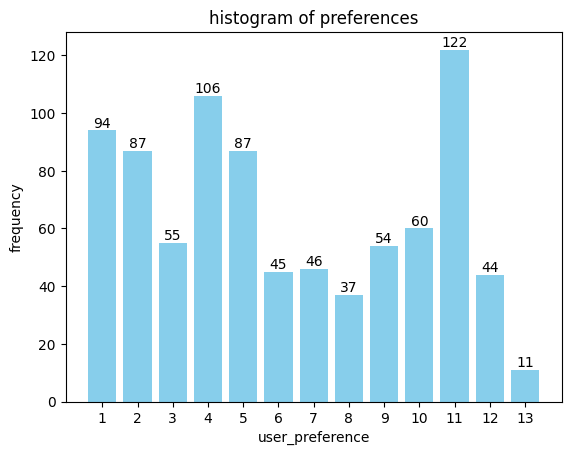

In [ ]:
plt.bar(num3['Numbers'], num3['counts'], color='skyblue')

# Add labels and title to the plot
plt.xlabel('user_preference')
plt.ylabel('frequency')
plt.title('histogram of preferences')
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12,13])
for i in range(len(num3)):
    count = num3['counts'][i]
    # print(count)
    plt.text(i+1, count, count, ha='center', va='bottom')
plt.show()


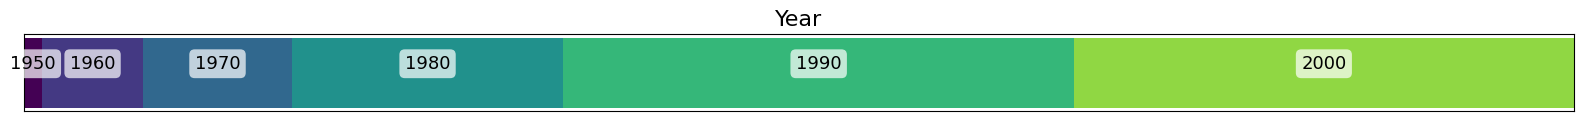

In [ ]:
counts = data['year'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels = [1950,1960,1970,1980,1990,2000]
# Specify the desired font size
label_fontsize = 13  # Change this value to adjust label size

Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Year', fontsize=16)
plt.show()

In [ ]:
data['degree'][data['degree']==6]=5
data2['degree'][data2['degree']==6]=5

<ipython-input-12-b48100e3aadf>:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['degree'][data['degree']==6]=5
<ipython-input-12-b48100e3aadf>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

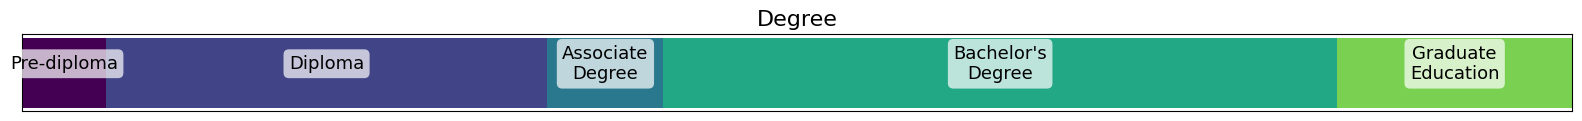

In [ ]:
counts = data['degree'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=['Pre-diploma','Diploma','Associate\nDegree',"Bachelor's\nDegree",'Graduate\nEducation']
# Specify the desired font size
label_fontsize = 13  # Change this value to adjust label size

Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Degree', fontsize=16)
plt.show()

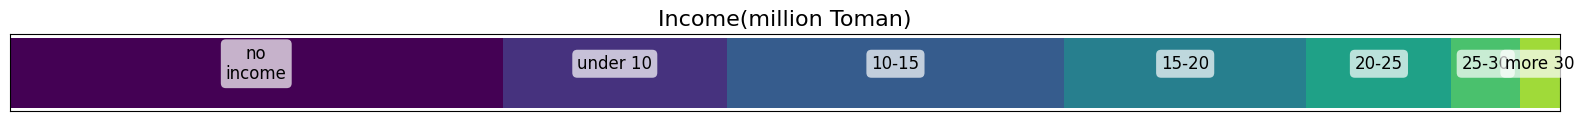

In [ ]:
counts = data['income'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=['no\nincome','under 10','10-15',"15-20",'20-25','25-30','more 30']
# Specify the desired font size
label_fontsize = 12  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Income(million Toman)', fontsize=16)
plt.show()

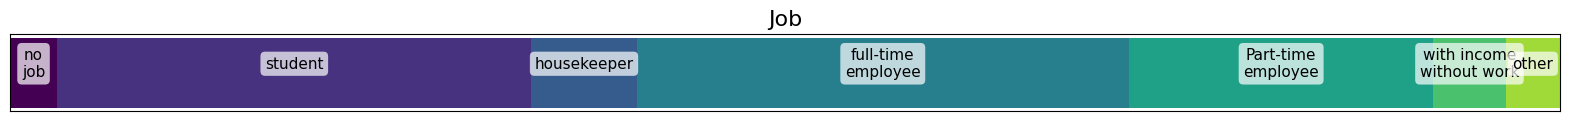

In [ ]:
counts = data3['شغل'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=['no\njob','student','housekeeper','full-time\nemployee',"Part-time\nemployee",'with income\nwithout work','other']
# Specify the desired font size
label_fontsize = 11 # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Job', fontsize=16)
plt.show()

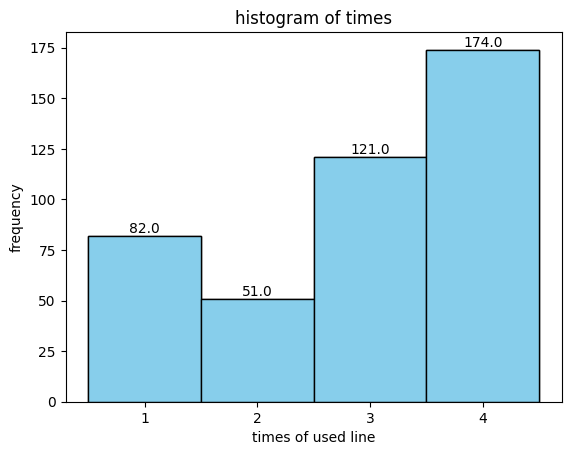

In [ ]:
bins = [0.5,1.5,2.5,3.5,4.5]
plt.hist(data3[1],bins=bins,color='skyblue', edgecolor='black', align='mid')
plt.xlabel('times of used line')
plt.ylabel('frequency')
plt.title('histogram of times')
plt.xticks([1,2,3,4])
hist_vals, bin_edges, _ = plt.hist(data3[1], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    plt.text(i+1, count, count, ha='center', va='bottom')
plt.show()

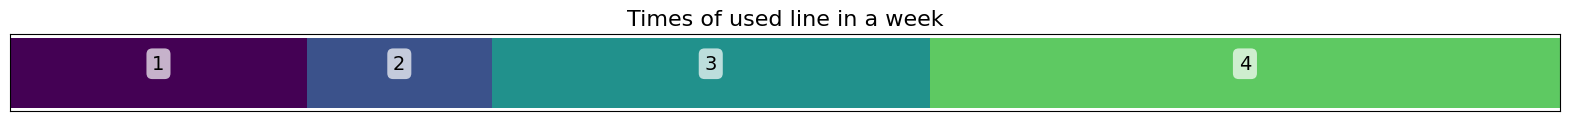

In [ ]:
counts = data3[1].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
cumulative = 0
labels = counts.index.astype(str)
# Specify the desired font size
label_fontsize = 14  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=str(key))  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{key}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Times of used line in a week', fontsize=16)
plt.show()

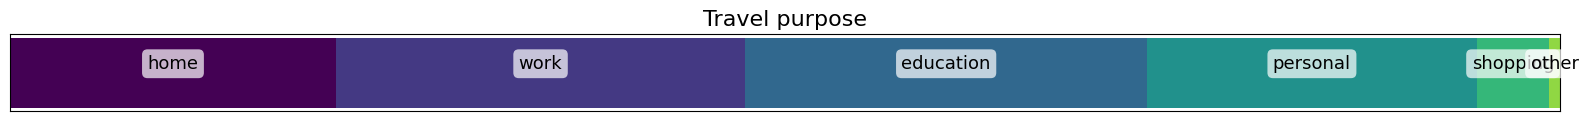

In [ ]:
counts = data3[3].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
cumulative = 0
labels=['home', 'work', 'education', 'personal', 'shopping','other']
# Specify the desired font size
label_fontsize = 13  # Change this value to adjust label size

# CreTate the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Travel purpose', fontsize=16)
plt.show()

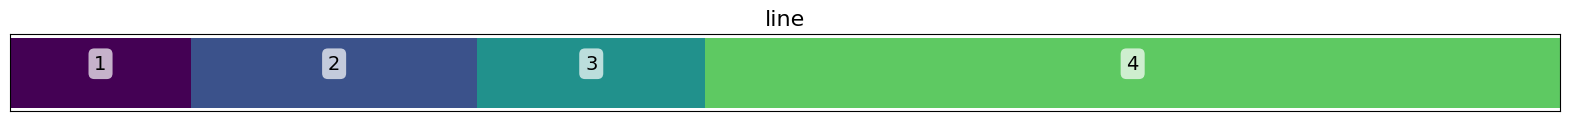

In [ ]:
counts = data3['خط'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
cumulative = 0
labels=[1,2,3,4]
# Specify the desired font size
label_fontsize = 14  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('line', fontsize=16)
plt.show()

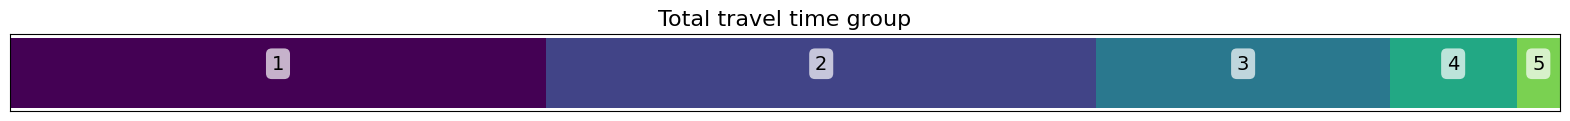

In [ ]:
counts = data['totall_duration_journey_group'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
cumulative = 0
labels=[1,2,3,4,5]
# Specify the desired font size
label_fontsize = 14  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Total travel time group', fontsize=16)
plt.show()

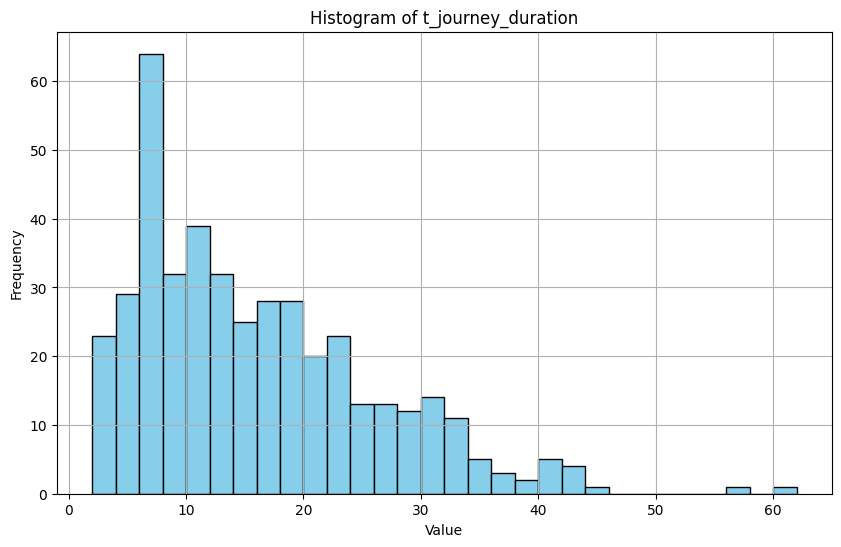

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(data['t_journey_duration'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of t_journey_duration')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid()
plt.show()

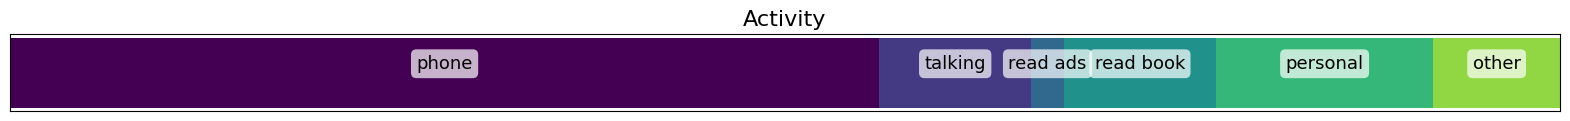

In [ ]:
counts = df['soal5'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
cumulative = 0
labels=['phone', 'talking', 'read ads', 'read book', 'personal','other']
# Specify the desired font size
label_fontsize = 13  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Activity', fontsize=16)
plt.show()

# 2-1.notice inside ad(yes)

In [ ]:
#inside_ad
data=pd.read_excel('/content/drive/MyDrive/thesis/final44.xlsx')

In [ ]:
data=data.drop(columns=[3])
df_in=data[data['adv']==1]

In [ ]:
df_in.columns

Index(['adv', 'origin_code', 'dist_code', 'hometrip', 'worktrip', 'edutrip',
       'personaltrip', 'shopingtrip', 'siting', 'transfer', 'year', 'age',
       'youngerbtw1370_1380', 'btw1380s', 'btw1370s', 'btw1360s', 'under1350s',
       't_journey_duration', 'totall_duration_journey_group',
       'exact_travel_time', 'time_class', 'travel_time_class_mean', 'male',
       'single', 'degree', 'job', 'employ_3_4_5_6_7', 'semi_employ_3_4',
       'full_employ_5_6_7', 'no_job_1_2', 'income', 'line1', 'line2', 'line3',
       'line4', 'crowded', 'peak', 'workandedutrip', 'totalpersonal',
       'noincom', 'income_under10', 'income_btwt10_15', 'income_btw15_20',
       'income_btw20_25', 'income_btw25_30', 'income_more30', 'lowincome',
       'medincome', 'highincome'],
      dtype='object')

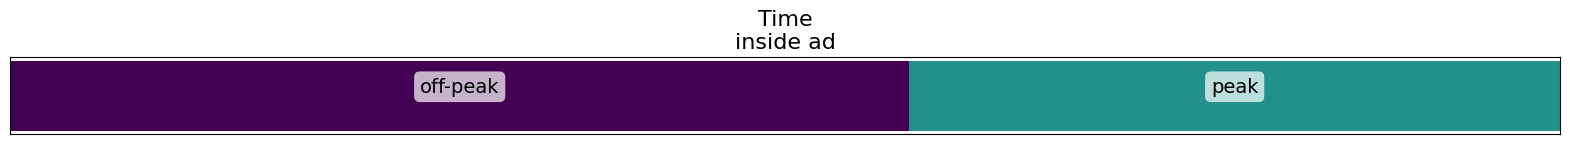

In [ ]:
counts = df_in['peak'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
labels=['off-peak','peak']
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
# Specify the desired font size
label_fontsize = 14  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Time\ninside ad', fontsize=16)
plt.show()

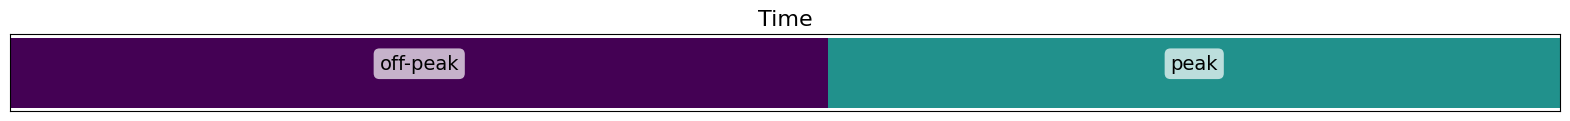

In [ ]:
counts = data['peak'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
labels=['off-peak','peak']
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
# Specify the desired font size
label_fontsize = 14  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Time', fontsize=16)
plt.show()

In [ ]:
df_in2=data3[data3['2-1.']==2]

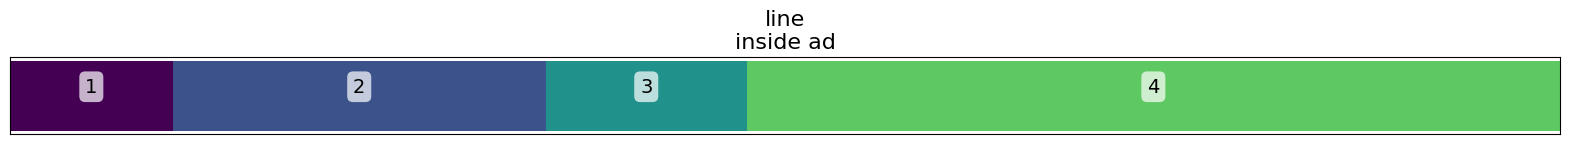

In [ ]:
counts = df_in2['خط'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=[1,2,3,4]
# Specify the desired font size
label_fontsize = 14  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('line\ninside ad', fontsize=16)
plt.show()

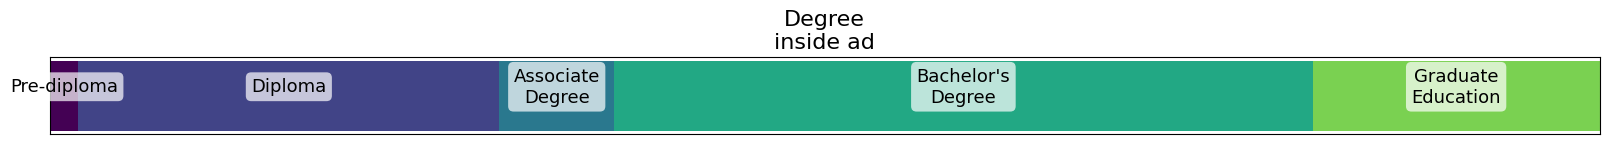

In [ ]:
counts = df_in['degree'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=['Pre-diploma','Diploma','Associate\nDegree',"Bachelor's\nDegree",'Graduate\nEducation']
# Specify the desired font size
label_fontsize = 13  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Degree\ninside ad', fontsize=16)
plt.show()

In [ ]:
ones = [1] * 248
zeros = [0] * 180

# Combine the two lists
result = ones + zeros

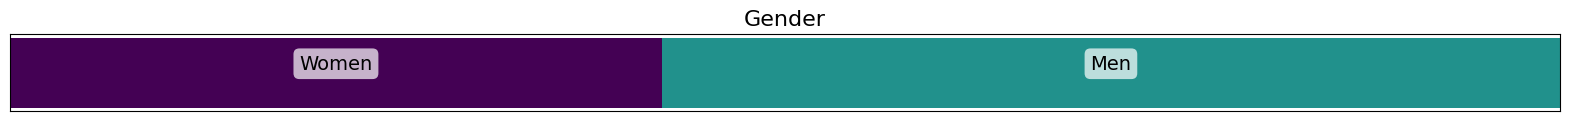

0    0.420561
1    0.579439
Name: count, dtype: float64


In [ ]:
my_series = pd.Series(result)
counts = my_series.value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=['Women','Men']
# Specify the desired font size
label_fontsize = 14  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Gender', fontsize=16)
plt.show()
print(proportions)

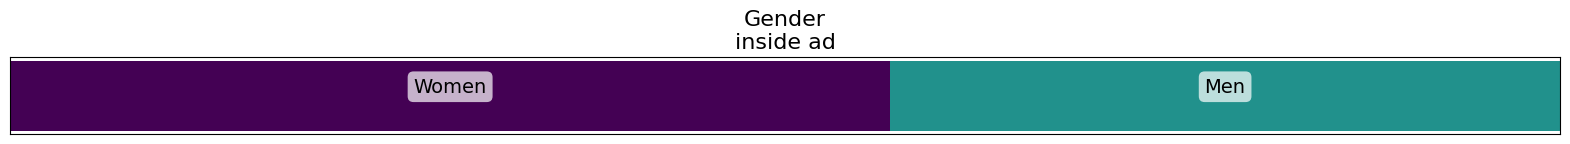

In [ ]:
counts = df_in['male'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=['Women','Men']
# Specify the desired font size
label_fontsize = 14  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Gender\ninside ad', fontsize=16)
plt.show()

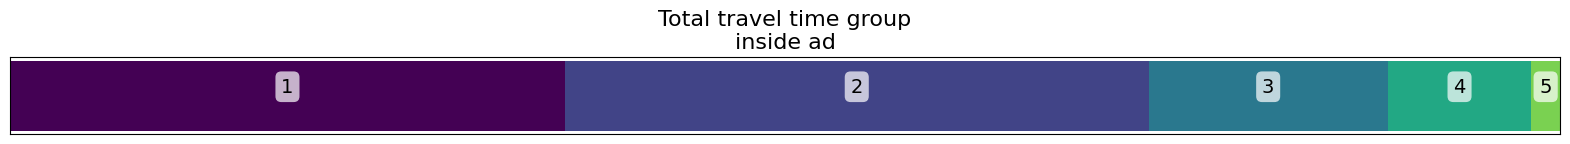

In [ ]:
counts = df_in['totall_duration_journey_group'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=[1,2,3,4,5]
# Specify the desired font size
label_fontsize = 14  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Total travel time group\ninside ad', fontsize=16)
plt.show()

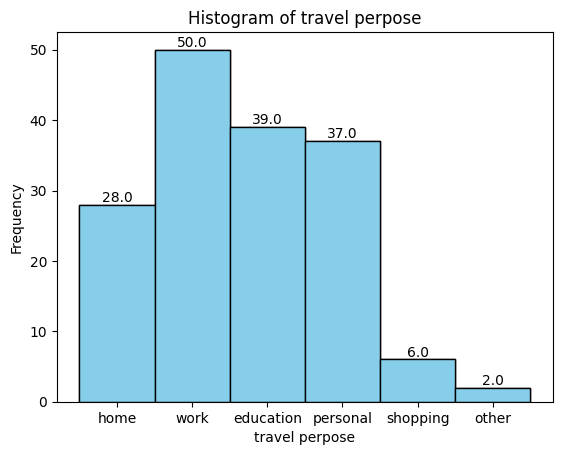

In [ ]:
bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5,6.5]
plt.hist(df_in2[3], bins=bins, color='skyblue', edgecolor='black', align='mid')
plt.xlabel('travel perpose')
plt.ylabel('Frequency')
plt.title('Histogram of travel perpose')
labels = ['home', 'work', 'education', 'personal', 'shopping','other']
plt.xticks([1, 2, 3, 4, 5,6], labels)

hist_vals, _, _ = plt.hist(df_in2[3], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    plt.text(i + 1, count, count, ha='center', va='bottom')

plt.show()

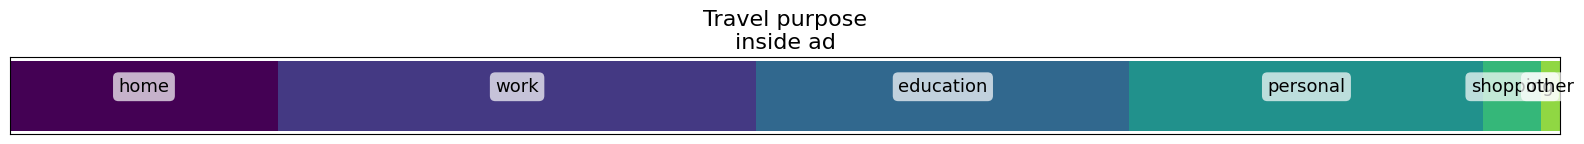

In [ ]:
counts = df_in2[3].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=['home', 'work', 'education', 'personal', 'shopping','other']
# Specify the desired font size
label_fontsize = 13 # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Travel purpose\ninside ad', fontsize=16)
plt.show()

In [ ]:
df2=df_in2[df_in2['اوج/غیراوج']==1]

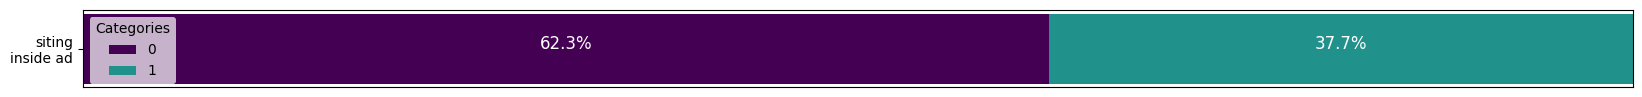

In [ ]:
counts = df_in['siting'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels = counts.index.astype(str)

for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('siting\ninside ad', proportion, color=colors[i], left=cumulative, label=str(key))  # Convert key to string for label
    cumulative += proportion
plt.xticks([])
plt.xlim(0, 1)

cumulative = 0
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.text(cumulative + proportion / 2, 0.05, f'{proportion:.1%}', ha='center', va='center', fontsize=12, color='white', )
    cumulative += proportion

plt.legend(title='Categories',loc='upper left' ,facecolor='white',edgecolor='none',framealpha=0.7 )

# Show the plot
plt.show()

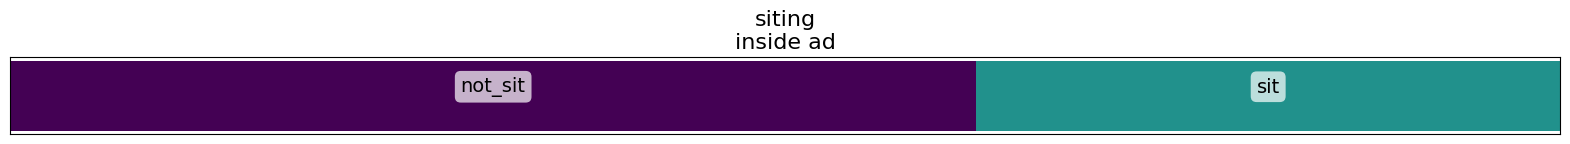

In [ ]:
counts = df_in['siting'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=['not_sit','sit']
# Specify the desired font size
label_fontsize = 14  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('siting\ninside ad', fontsize=16)
plt.show()

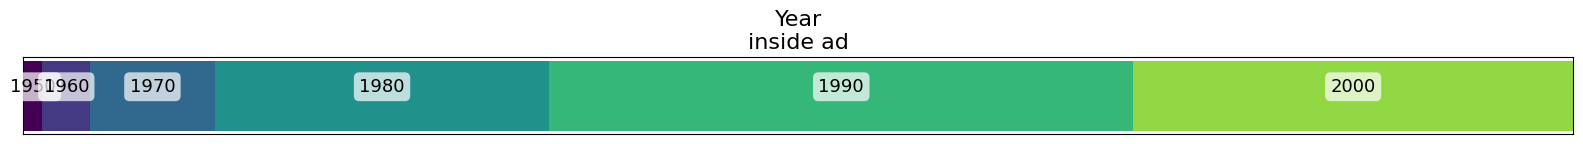

In [ ]:
counts = df_in['year'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=[1950,1960,1970,1980,1990,2000]
# Specify the desired font size
label_fontsize = 13  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Year\ninside ad', fontsize=16)
plt.show()

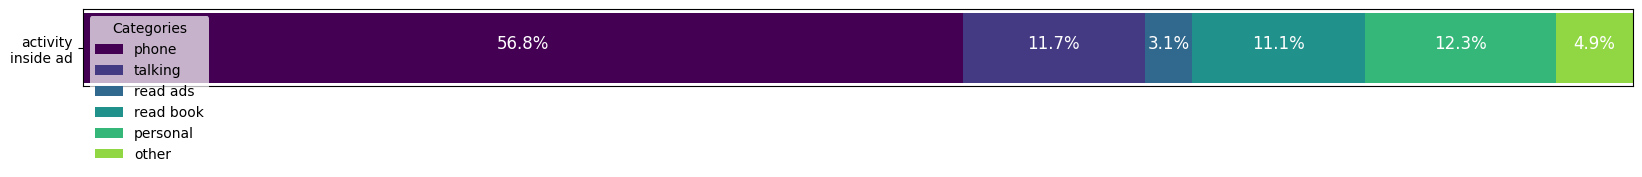

In [ ]:
counts = df_in2[5].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels = counts.index.astype(str)

for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('activity\ninside ad', proportion, color=colors[i], left=cumulative, label=str(key))  # Convert key to string for label
    cumulative += proportion
plt.xticks([])
plt.xlim(0, 1)

cumulative = 0
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.text(cumulative + proportion / 2, 0.05, f'{proportion:.1%}', ha='center', va='center', fontsize=12, color='white', )
    cumulative += proportion

plt.legend(title='Categories',loc='upper left' ,facecolor='white',edgecolor='none',framealpha=0.7 , labels=['phone', 'talking', 'read ads', 'read book', 'personal','other'])

# Show the plot
plt.show()

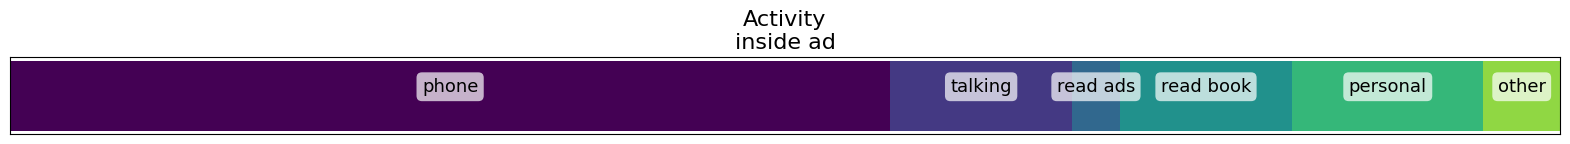

In [ ]:
counts = df_in2[5].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=['phone', 'talking', 'read ads', 'read book', 'personal','other']
# Specify the desired font size
label_fontsize = 13  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Activity\ninside ad', fontsize=16)
plt.show()

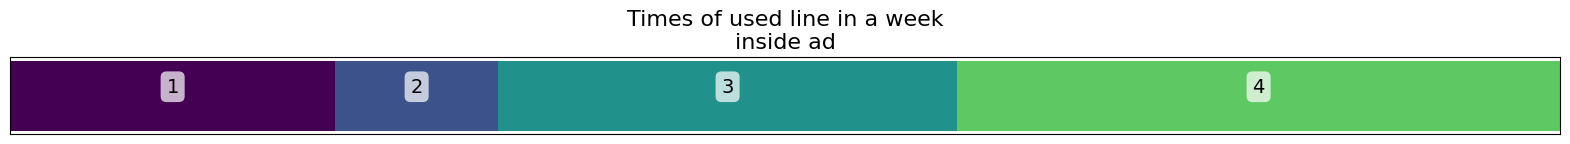

In [ ]:
counts = df_in2[1].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=[1,2,3,4]
# Specify the desired font size
label_fontsize = 14  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Times of used line in a week\ninside ad', fontsize=16)
plt.show()

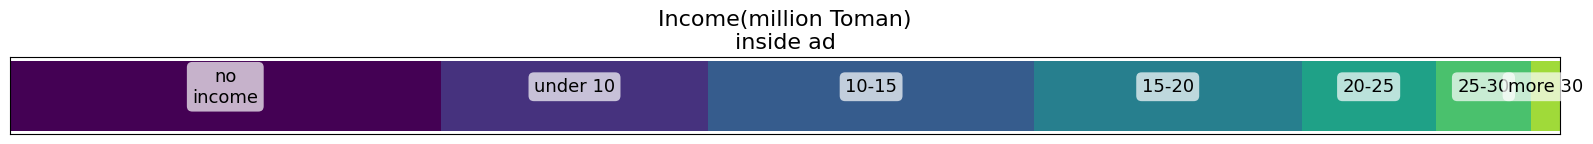

In [ ]:
counts = df_in['income'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=['no\nincome','under 10','10-15',"15-20",'20-25','25-30','more 30']
# Specify the desired font size
label_fontsize = 13  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Income(million Toman)\ninside ad', fontsize=16)
plt.show()

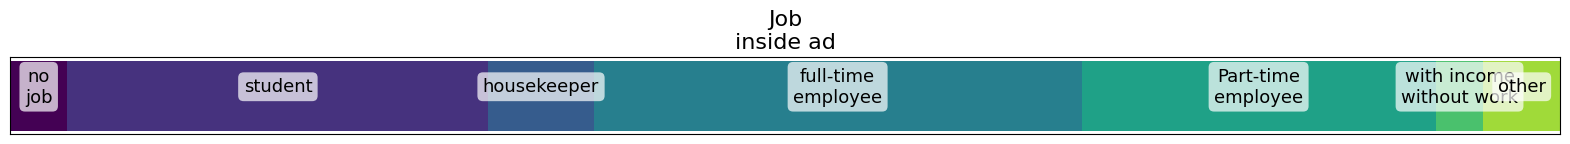

In [ ]:
counts = df_in2['شغل'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=['no\njob','student','housekeeper','full-time\nemployee',"Part-time\nemployee",'with income\nwithout work','other']
# Specify the desired font size
label_fontsize = 13  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Job\ninside ad', fontsize=16)
plt.show()

# 3-1.notice outside ad(yes)

In [ ]:
df_out=data2[data2['adv_out']==1]

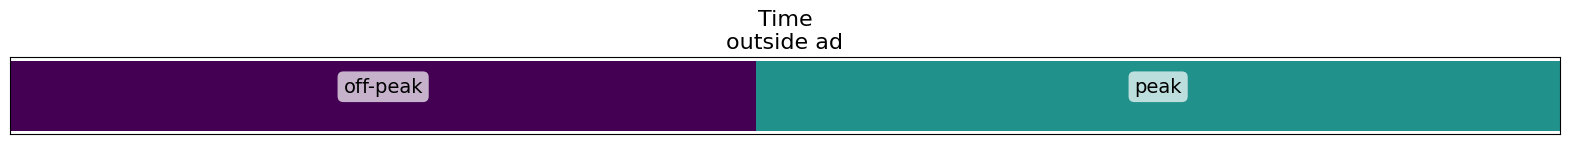

In [ ]:
counts = df_out['peak'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=['off-peak','peak']
# Specify the desired font size
label_fontsize = 14  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Time\noutside ad', fontsize=16)
plt.show()

In [ ]:
df_out['line']=0

<ipython-input-46-61fac01692ba>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_out['line']=0


In [ ]:
df_out['line'][df_out['line1']==1]=1
df_out['line'][df_out['line2']==1]=2
df_out['line'][df_out['line3']==1]=3
df_out['line'][df_out['line4']==1]=4

<ipython-input-47-5bb4c7bd6f40>:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_out['line'][df_out['line1']==1]=1
<ipython-input-47-5bb4c7bd6f40>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFra

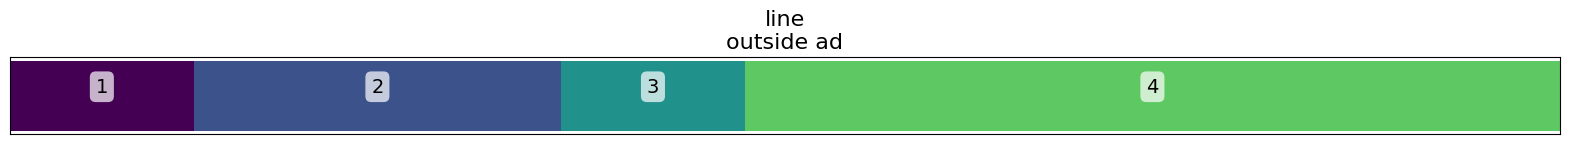

In [ ]:
counts = df_out['line'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=[1,2,3,4]
# Specify the desired font size
label_fontsize = 14  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('line\noutside ad', fontsize=16)
plt.show()

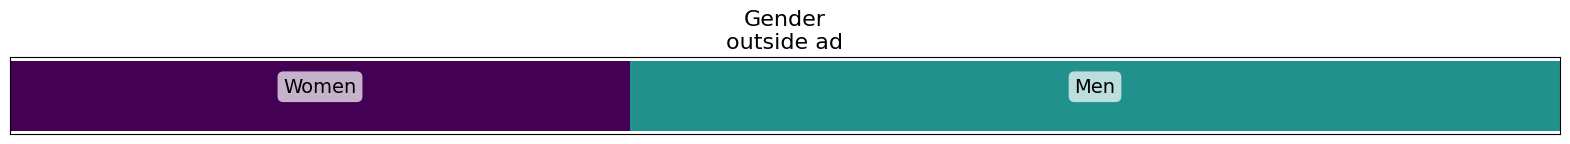

In [ ]:
counts = df_out['male'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=['Women','Men']
# Specify the desired font size
label_fontsize = 14  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Gender\noutside ad', fontsize=16)
plt.show()

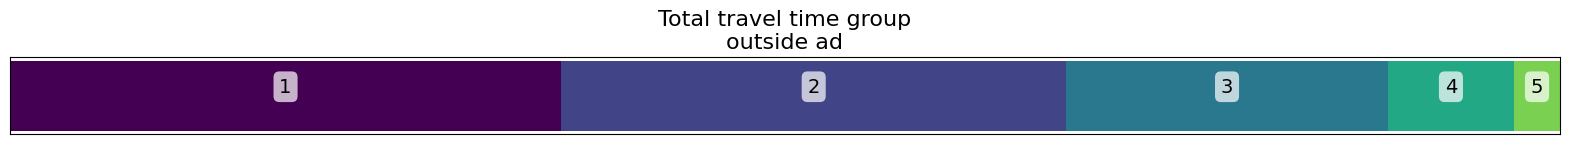

In [ ]:
counts = df_out['totall_duration_journey_group'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=[1,2,3,4,5]
# Specify the desired font size
label_fontsize = 14  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Total travel time group\noutside ad', fontsize=16)
plt.show()

In [ ]:
df_out['purpose']=0

<ipython-input-52-33fb02afb8e9>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_out['purpose']=0


In [ ]:
df_out['purpose'][df_out['edutrip']==1]=3
df_out['purpose'][df_out['hometrip']==1]=1
df_out['purpose'][df_out['worktrip']==1]=2
df_out['purpose'][df_out['shopingtrip']==1]=5
df_out['purpose'][df_out['personaltrip']==1]=4
df_out['purpose'][df_out['purpose']==0]=6

<ipython-input-53-cea33ab5b0cf>:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_out['purpose'][df_out['edutrip']==1]=3
<ipython-input-53-cea33ab5b0cf>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

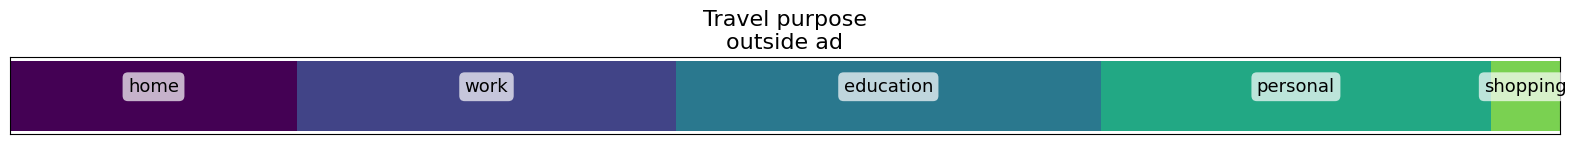

In [ ]:
counts = df_out['purpose'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=['home', 'work', 'education', 'personal', 'shopping','other']
# Specify the desired font size
label_fontsize = 13  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Travel purpose\noutside ad', fontsize=16)
plt.show()

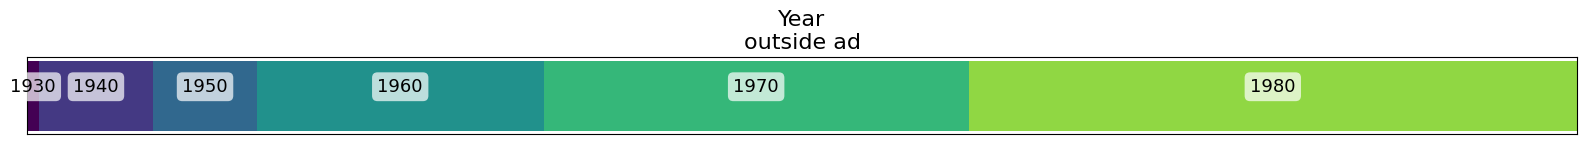

In [ ]:
counts = df_out['year'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=[1930,1940,1950,1960,1970,1980]
# Specify the desired font size
label_fontsize = 13  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Year\noutside ad', fontsize=16)
plt.show()

In [ ]:
df_out2=df[df['adv_out']==1]

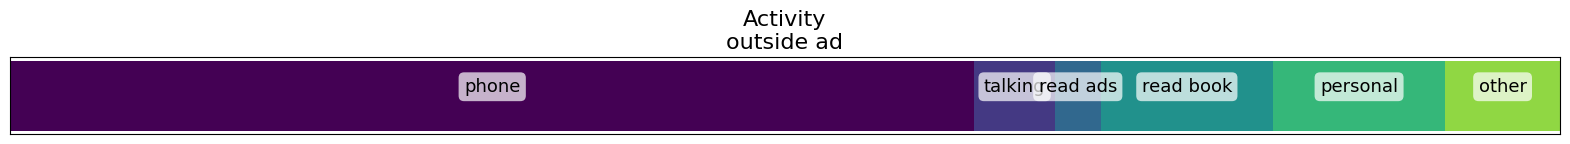

In [ ]:
counts =  df_out2['soal5'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=['phone', 'talking', 'read ads', 'read book', 'personal','other']
# Specify the desired font size
label_fontsize = 13  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Activity\noutside ad', fontsize=16)
plt.show()

In [ ]:
df_out['times']=data3[1]

<ipython-input-58-b9ac990333df>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_out['times']=data3[1]


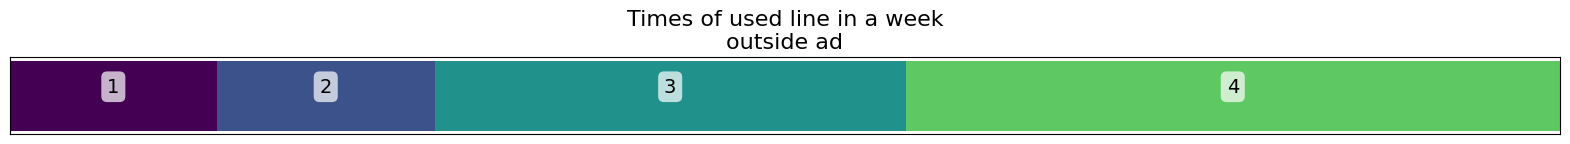

In [ ]:
counts =  df_out['times'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=[1,2,3,4]
# Specify the desired font size
label_fontsize = 14  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Times of used line in a week\noutside ad', fontsize=16)
plt.show()

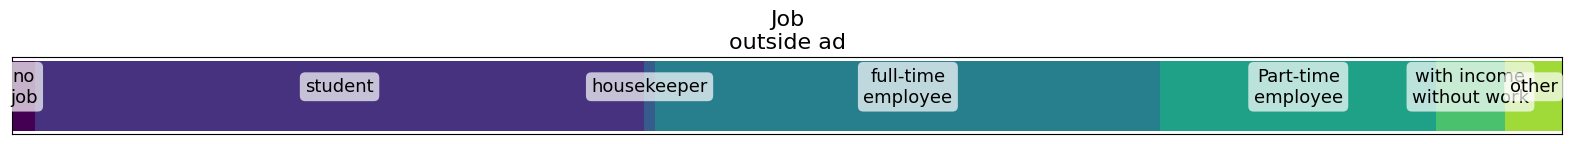

In [ ]:
counts = df_out['job'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=['no\njob','student','housekeeper','full-time\nemployee',"Part-time\nemployee",'with income\nwithout work','other']
# Specify the desired font size
label_fontsize = 13  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Job\noutside ad', fontsize=16)
plt.show()

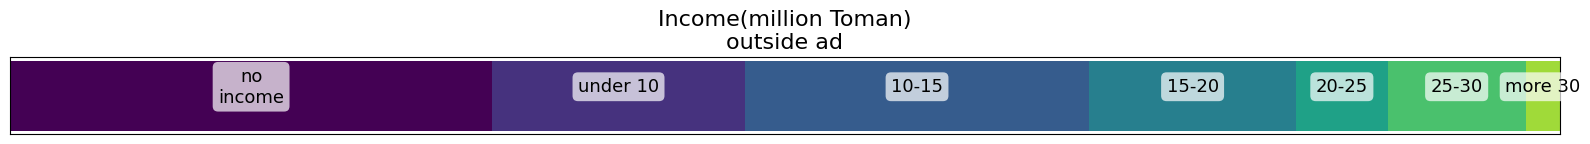

In [ ]:
counts = df_out['income'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=['no\nincome','under 10','10-15',"15-20",'20-25','25-30','more 30']
# Specify the desired font size
label_fontsize = 13  # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Income(million Toman)\noutside ad', fontsize=16)
plt.show()

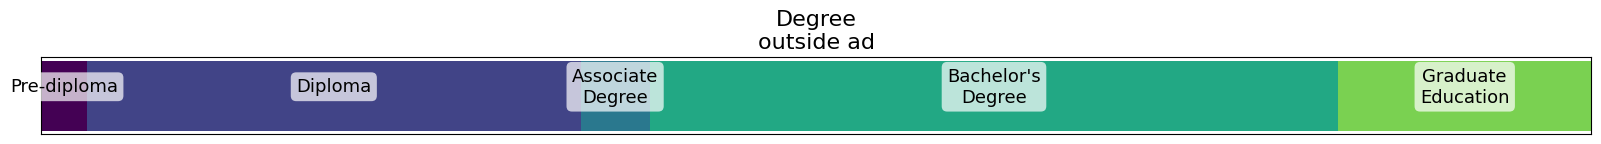

In [ ]:
counts = df_out['degree'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total

plt.figure(figsize=(20, 1))

cumulative = 0
colors = plt.cm.viridis([i / len(counts) for i in range(len(counts))])
labels=['Pre-diploma','Diploma','Associate\nDegree',"Bachelor's\nDegree",'Graduate\nEducation']
# Specify the desired font size
label_fontsize = 13 # Change this value to adjust label size

# Create the horizontal bars with labels
for i, (key, proportion) in enumerate(zip(counts.index, proportions)):
    plt.barh('year', proportion, color=colors[i], left=cumulative, label=labels[i])  # Use 0 for the y-value

    # Add text label centered above the bar with a background
    plt.text(cumulative + proportion / 2, 0.1, f'{labels[i]}',
             ha='center', va='center', fontsize=label_fontsize, color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    cumulative += proportion

# Hide x-ticks and adjust limits
plt.xticks([])
plt.xlim(0, 1)

plt.yticks([])
plt.title('Degree\noutside ad', fontsize=16)
plt.show()

# **prepration(part2)**

In [ ]:
from scipy.stats import chi2_contingency


In [ ]:
df=pd.read_excel('/content/drive/MyDrive/thesis/data_decisionTree.xlsx')

In [ ]:
df.loc[df['user_pref'] == 2, 'user_pref'] = 1
df.loc[df['user_pref'] == 3, 'user_pref'] = 1
df.loc[df['user_pref'] == 4, 'user_pref'] = 1
df.loc[df['user_pref'] == 5, 'user_pref'] = 2
df.loc[df['user_pref'] == 6, 'user_pref'] = 2
df.loc[df['user_pref'] == 7, 'user_pref'] = 2
df.loc[df['user_pref'] == 8, 'user_pref'] = 2
df.loc[df['user_pref'] == 9, 'user_pref'] = 3
df.loc[df['user_pref'] == 10, 'user_pref'] = 3
df.loc[df['user_pref'] == 11, 'user_pref'] = 3
df.loc[df['user_pref'] == 12, 'user_pref'] = 3

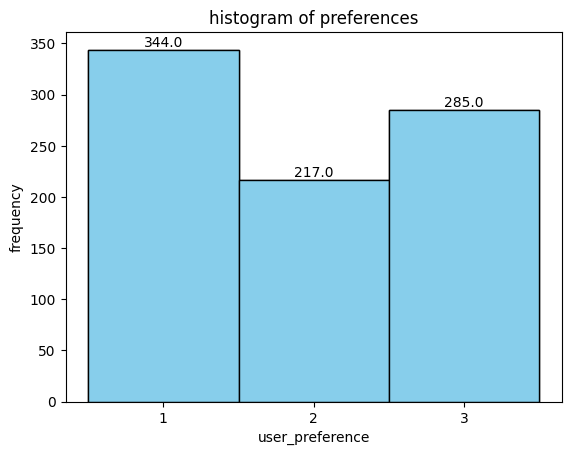

In [ ]:
bins = [0.5,1.5,2.5,3.5]
plt.hist(df['user_pref'],bins=bins,color='skyblue', edgecolor='black', align='mid')
plt.xlabel('user_preference')
plt.ylabel('frequency')
plt.title('histogram of preferences')
plt.xticks([1,2,3])
hist_vals, bin_edges, _ = plt.hist(df['user_pref'], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    plt.text(i+1, count, count, ha='center', va='bottom')
plt.show()

In [ ]:
df1=df[df['user_pref'] == 1]

In [ ]:
df.loc[df['user_pref'] == 1, 'user_pref'] = 1
df.loc[df['user_pref'] == 2, 'user_pref'] = 0
df.loc[df['user_pref'] == 3, 'user_pref'] = 0

In [ ]:
contingency_table = pd.crosstab(df['user_pref'], df['peak'])

print("Contingency Table:")
print(contingency_table)

# Perform Chi-Square Test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degrees of freedom: {dof}")
print("Expected Frequencies:")
print(expected)

# Interpret the result
alpha = 0.1
if p < alpha:
    print("Reject the null hypothesis: there is a significant association.")
else:
    print("Fail to reject the null hypothesis: no significant association.")

Contingency Table:
peak         0    1
user_pref          
0          265  237
1          188  156

Chi-Square Statistic: 0.2146640517474372
p-value: 0.6431360721891161
Degrees of freedom: 1
Expected Frequencies:
[[268.80141844 233.19858156]
 [184.19858156 159.80141844]]
Fail to reject the null hypothesis: no significant association.


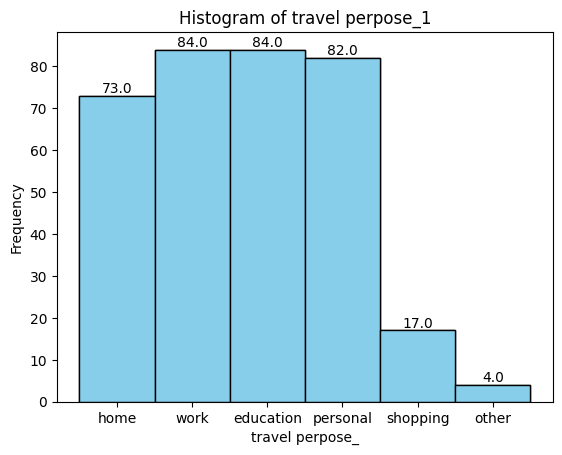

In [ ]:
bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5,6.5]
plt.hist(df1['trip_purpose'], bins=bins, color='skyblue', edgecolor='black', align='mid')
plt.xlabel('travel perpose_')
plt.ylabel('Frequency')
plt.title('Histogram of travel perpose_1')
labels = ['home', 'work', 'education', 'personal', 'shopping','other']
plt.xticks([1, 2, 3, 4, 5,6], labels)

hist_vals, _, _ = plt.hist(df1['trip_purpose'], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    plt.text(i + 1, count, count, ha='center', va='bottom')

plt.show()

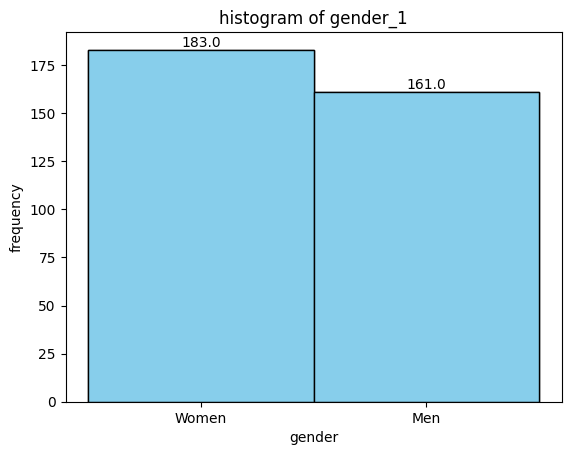

In [ ]:
bins = [-0.5,0.5,1.5]
plt.hist(df1['male'],bins=bins,color='skyblue', edgecolor='black', align='mid')
plt.xlabel('gender')
plt.ylabel('frequency')
plt.title('histogram of gender_1')
labels=['Women','Men']
plt.xticks([0,1],labels)
hist_vals, bin_edges, _ = plt.hist(df1['male'], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    # print(count)
    plt.text(i, count, count, ha='center', va='bottom')
plt.show()

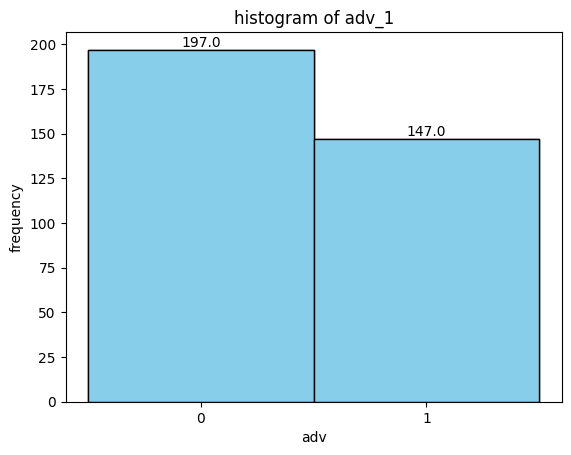

In [ ]:
bins = [-0.5,0.5,1.5]
plt.hist(df1['adv'],bins=bins,color='skyblue', edgecolor='black', align='mid')
plt.xlabel('adv')
plt.ylabel('frequency')
plt.title('histogram of adv_1')
plt.xticks([0,1])
hist_vals, bin_edges, _ = plt.hist(df1['adv'], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    # print(count)
    plt.text(i, count, count, ha='center', va='bottom')
plt.show()

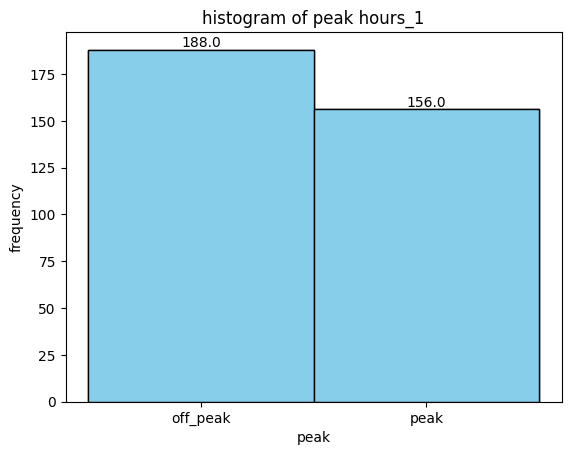

In [ ]:
bins = [-0.5,0.5,1.5]
plt.hist(df1['peak'],bins=bins,color='skyblue', edgecolor='black', align='mid')
plt.xlabel('peak')
plt.ylabel('frequency')
plt.title('histogram of peak hours_1')
labels=['off_peak','peak']
plt.xticks([0,1],labels)
hist_vals, bin_edges, _ = plt.hist(df1['peak'], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    # print(count)
    plt.text(i, count, count, ha='center', va='bottom')
plt.show()

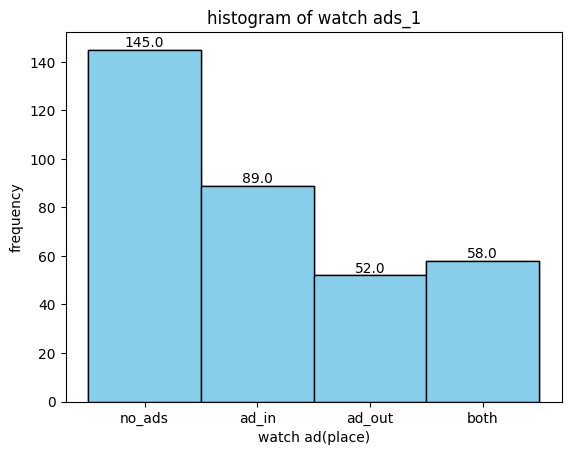

In [ ]:
bins = [-0.5,0.5,1.5,2.5,3.5]
plt.hist(df1['adv_place(0=no,1=adv_in,2=adv_out,3=both)'],bins=bins,color='skyblue', edgecolor='black', align='mid')
plt.xlabel('watch ad(place)')
plt.ylabel('frequency')
plt.title('histogram of watch ads_1')
labels=['no_ads','ad_in','ad_out','both']
plt.xticks([0,1,2,3],labels)
hist_vals, bin_edges, _ = plt.hist(df1['adv_place(0=no,1=adv_in,2=adv_out,3=both)'], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    plt.text(i, count, count, ha='center', va='bottom')
plt.show()

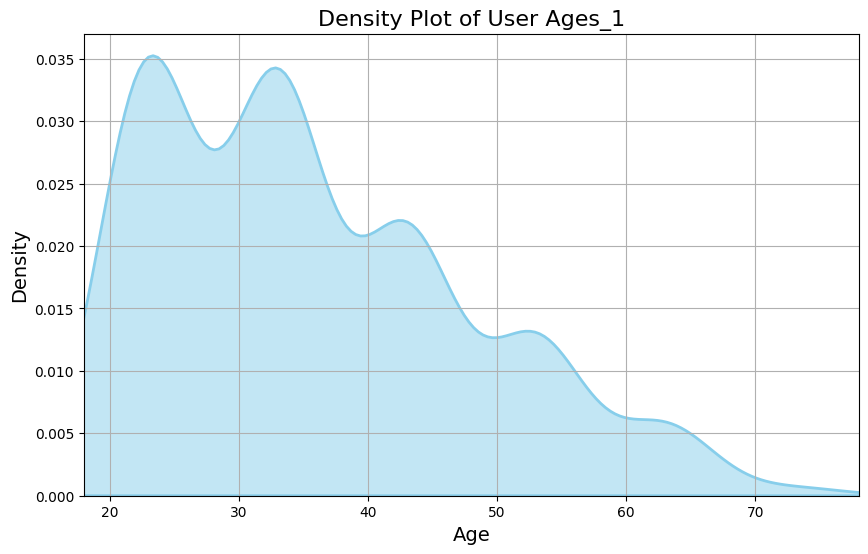

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df1['age'], fill=True, color='skyblue', alpha=0.5, lw=2)

# Add labels and title
plt.title('Density Plot of User Ages_1', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.xlim(df1['age'].min() - 5, df1['age'].max() + 5)  # adjust limits for better visualization
plt.grid(True)

# Show the plot
plt.show()

In [ ]:
df2=df[df['user_pref'] == 2]

In [ ]:
df.loc[df['user_pref'] == 1, 'user_pref'] = 0
df.loc[df['user_pref'] == 2, 'user_pref'] = 1
df.loc[df['user_pref'] == 3, 'user_pref'] = 0

In [ ]:
contingency_table = pd.crosstab(df['user_pref'], df['adv_place(0=no,1=adv_in,2=adv_out,3=both)'])

print("Contingency Table:")
print(contingency_table)

# Perform Chi-Square Test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degrees of freedom: {dof}")
print("Expected Frequencies:")
print(expected)

# Interpret the result
alpha = 0.1
if p < alpha:
    print("Reject the null hypothesis: there is a significant association.")
else:
    print("Fail to reject the null hypothesis: no significant association.")

Contingency Table:
adv_place(0=no,1=adv_in,2=adv_out,3=both)    0    1    2    3
user_pref                                                    
0                                          263  159  105  102
1                                           81   55   38   43

Chi-Square Statistic: 2.0820180272502036
p-value: 0.5555591963923032
Degrees of freedom: 3
Expected Frequencies:
[[255.76359338 159.10874704 106.32033097 107.80732861]
 [ 88.23640662  54.89125296  36.67966903  37.19267139]]
Fail to reject the null hypothesis: no significant association.


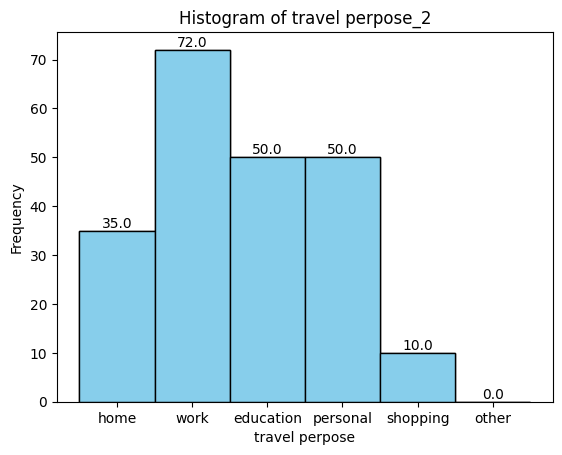

In [ ]:
bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5,6.5]
plt.hist(df2['trip_purpose'], bins=bins, color='skyblue', edgecolor='black', align='mid')
plt.xlabel('travel perpose')
plt.ylabel('Frequency')
plt.title('Histogram of travel perpose_2')
labels = ['home', 'work', 'education', 'personal', 'shopping','other']
plt.xticks([1, 2, 3, 4, 5,6], labels)

hist_vals, _, _ = plt.hist(df2['trip_purpose'], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    plt.text(i + 1, count, count, ha='center', va='bottom')

plt.show()

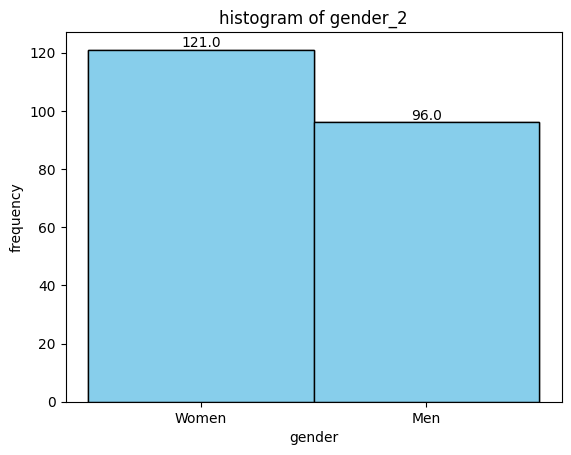

In [ ]:
bins = [-0.5,0.5,1.5]
plt.hist(df2['male'],bins=bins,color='skyblue', edgecolor='black', align='mid')
plt.xlabel('gender')
plt.ylabel('frequency')
plt.title('histogram of gender_2')
labels=['Women','Men']
plt.xticks([0,1],labels)
hist_vals, bin_edges, _ = plt.hist(df2['male'], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    # print(count)
    plt.text(i, count, count, ha='center', va='bottom')
plt.show()

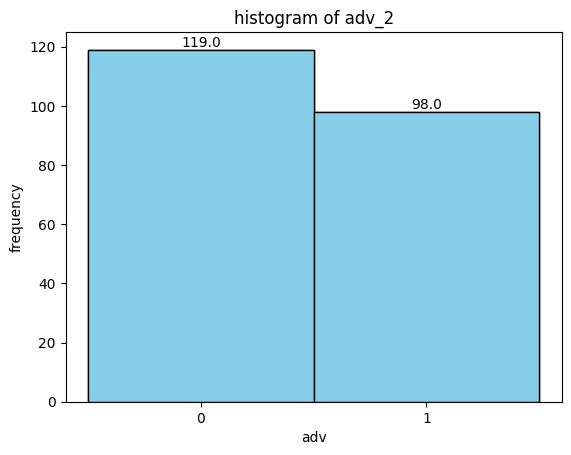

In [ ]:
bins = [-0.5,0.5,1.5]
plt.hist(df2['adv'],bins=bins,color='skyblue', edgecolor='black', align='mid')
plt.xlabel('adv')
plt.ylabel('frequency')
plt.title('histogram of adv_2')
plt.xticks([0,1])
hist_vals, bin_edges, _ = plt.hist(df2['adv'], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    # print(count)
    plt.text(i, count, count, ha='center', va='bottom')
plt.show()

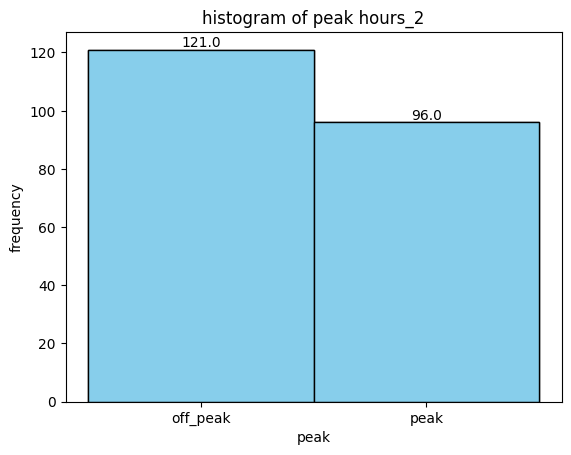

In [ ]:
bins = [-0.5,0.5,1.5]
plt.hist(df2['peak'],bins=bins,color='skyblue', edgecolor='black', align='mid')
plt.xlabel('peak')
plt.ylabel('frequency')
plt.title('histogram of peak hours_2')
labels=['off_peak','peak']
plt.xticks([0,1],labels)
hist_vals, bin_edges, _ = plt.hist(df2['peak'], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    # print(count)
    plt.text(i, count, count, ha='center', va='bottom')
plt.show()

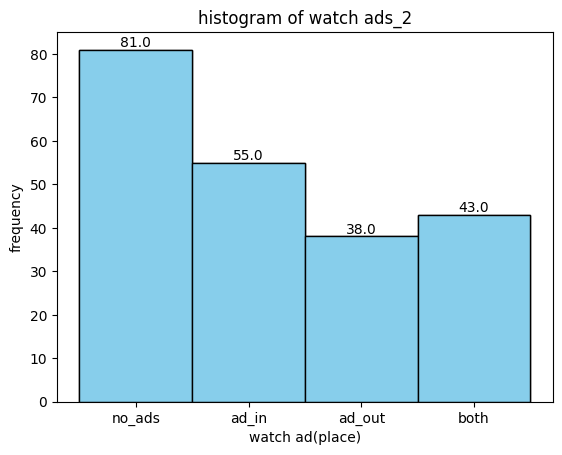

In [ ]:
bins = [-0.5,0.5,1.5,2.5,3.5]
plt.hist(df2['adv_place(0=no,1=adv_in,2=adv_out,3=both)'],bins=bins,color='skyblue', edgecolor='black', align='mid')
plt.xlabel('watch ad(place)')
plt.ylabel('frequency')
plt.title('histogram of watch ads_2')
labels=['no_ads','ad_in','ad_out','both']
plt.xticks([0,1,2,3],labels)
hist_vals, bin_edges, _ = plt.hist(df2['adv_place(0=no,1=adv_in,2=adv_out,3=both)'], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    plt.text(i, count, count, ha='center', va='bottom')
plt.show()

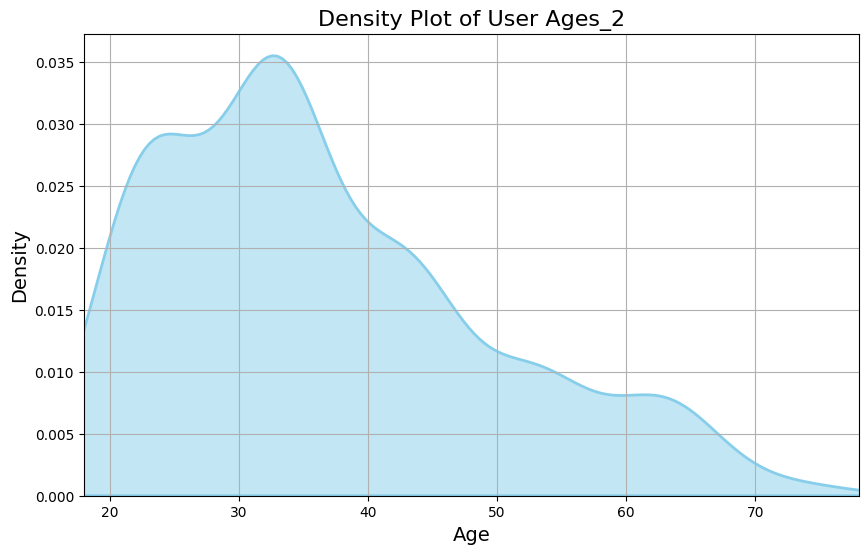

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df2['age'], fill=True, color='skyblue', alpha=0.5, lw=2)

# Add labels and title
plt.title('Density Plot of User Ages_2', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.xlim(df2['age'].min() - 5, df2['age'].max() + 5)  # adjust limits for better visualization
plt.grid(True)

# Show the plot
plt.show()

In [ ]:
df3=df[df['user_pref'] == 3]

In [ ]:
df.loc[df['user_pref'] == 1, 'user_pref'] = 0
df.loc[df['user_pref'] == 2, 'user_pref'] = 0
df.loc[df['user_pref'] == 3, 'user_pref'] = 1

In [ ]:
contingency_table = pd.crosstab(df['user_pref'], df['adv_place(0=no,1=adv_in,2=adv_out,3=both)'])

print("Contingency Table:")
print(contingency_table)

# Perform Chi-Square Test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degrees of freedom: {dof}")
print("Expected Frequencies:")
print(expected)

# Interpret the result
alpha = 0.1
if p < alpha:
    print("Reject the null hypothesis: there is a significant association.")
else:
    print("Fail to reject the null hypothesis: no significant association.")

Contingency Table:
adv_place(0=no,1=adv_in,2=adv_out,3=both)    0    1   2    3
user_pref                                                   
0                                          226  144  90  101
1                                          118   70  53   44

Chi-Square Statistic: 1.6042805638222783
p-value: 0.6584196204996673
Degrees of freedom: 3
Expected Frequencies:
[[228.11347518 141.90780142  94.82624113  96.15248227]
 [115.88652482  72.09219858  48.17375887  48.84751773]]
Fail to reject the null hypothesis: no significant association.


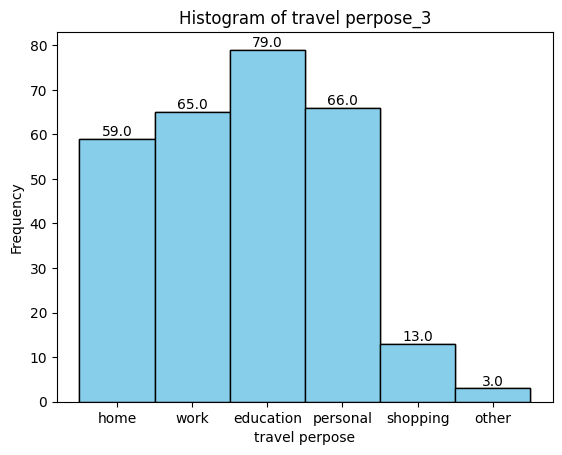

In [ ]:
bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5,6.5]
plt.hist(df3['trip_purpose'], bins=bins, color='skyblue', edgecolor='black', align='mid')
plt.xlabel('travel perpose')
plt.ylabel('Frequency')
plt.title('Histogram of travel perpose_3')
labels = ['home', 'work', 'education', 'personal', 'shopping','other']
plt.xticks([1, 2, 3, 4, 5,6], labels)

hist_vals, _, _ = plt.hist(df3['trip_purpose'], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    plt.text(i + 1, count, count, ha='center', va='bottom')

plt.show()

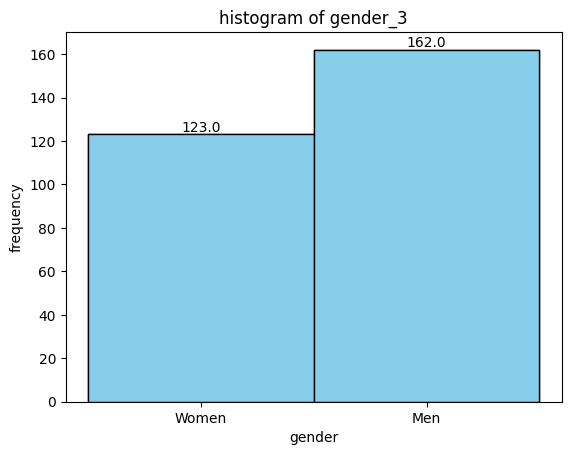

In [ ]:
bins = [-0.5,0.5,1.5]
plt.hist(df3['male'],bins=bins,color='skyblue', edgecolor='black', align='mid')
plt.xlabel('gender')
plt.ylabel('frequency')
plt.title('histogram of gender_3')
labels=['Women','Men']
plt.xticks([0,1],labels)
hist_vals, bin_edges, _ = plt.hist(df3['male'], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    # print(count)
    plt.text(i, count, count, ha='center', va='bottom')
plt.show()

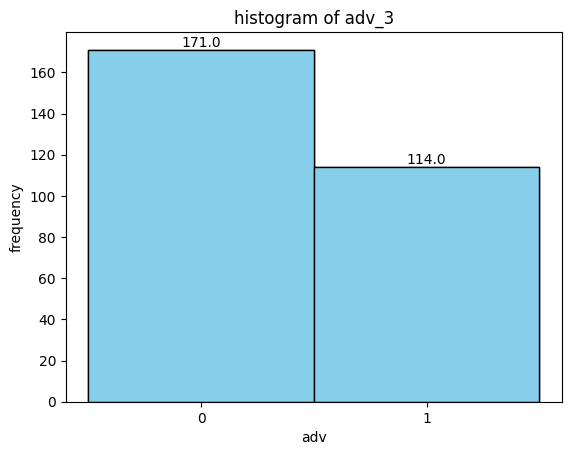

In [ ]:
bins = [-0.5,0.5,1.5]
plt.hist(df3['adv'],bins=bins,color='skyblue', edgecolor='black', align='mid')
plt.xlabel('adv')
plt.ylabel('frequency')
plt.title('histogram of adv_3')
plt.xticks([0,1])
hist_vals, bin_edges, _ = plt.hist(df3['adv'], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    # print(count)
    plt.text(i, count, count, ha='center', va='bottom')
plt.show()

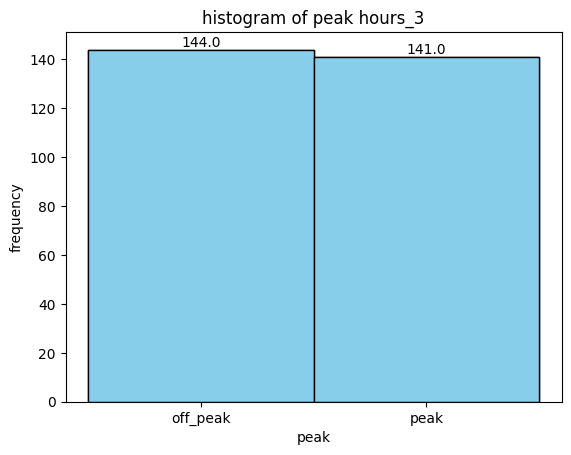

In [ ]:
bins = [-0.5,0.5,1.5]
plt.hist(df3['peak'],bins=bins,color='skyblue', edgecolor='black', align='mid')
plt.xlabel('peak')
plt.ylabel('frequency')
plt.title('histogram of peak hours_3')
labels=['off_peak','peak']
plt.xticks([0,1],labels)
hist_vals, bin_edges, _ = plt.hist(df3['peak'], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    # print(count)
    plt.text(i, count, count, ha='center', va='bottom')
plt.show()

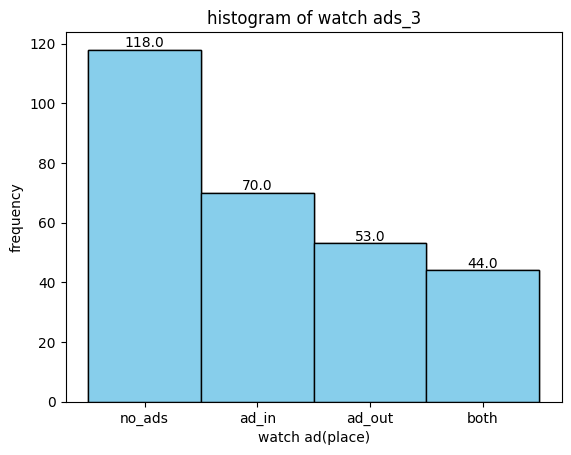

In [ ]:
bins = [-0.5,0.5,1.5,2.5,3.5]
plt.hist(df3['adv_place(0=no,1=adv_in,2=adv_out,3=both)'],bins=bins,color='skyblue', edgecolor='black', align='mid')
plt.xlabel('watch ad(place)')
plt.ylabel('frequency')
plt.title('histogram of watch ads_3')
labels=['no_ads','ad_in','ad_out','both']
plt.xticks([0,1,2,3],labels)
hist_vals, bin_edges, _ = plt.hist(df3['adv_place(0=no,1=adv_in,2=adv_out,3=both)'], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    plt.text(i, count, count, ha='center', va='bottom')
plt.show()

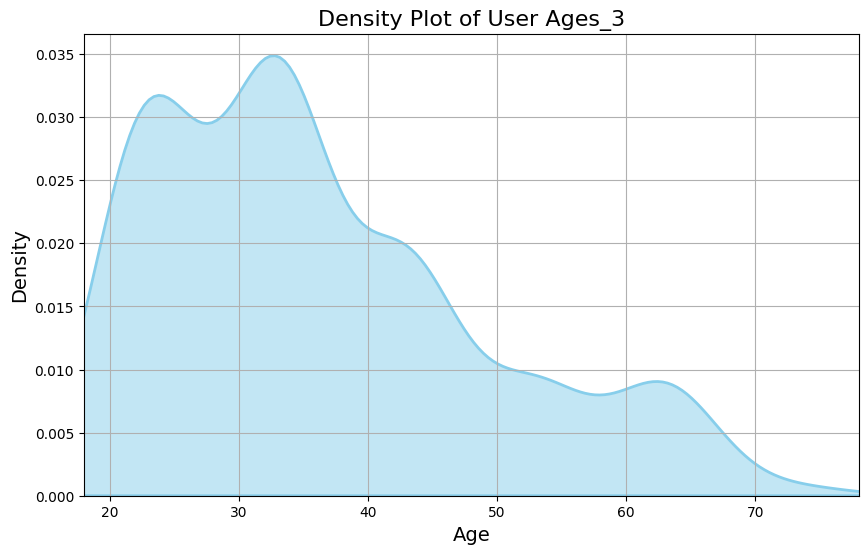

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df3['age'], fill=True, color='skyblue', alpha=0.5, lw=2)

# Add labels and title
plt.title('Density Plot of User Ages_3', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.xlim(df3['age'].min() - 5, df3['age'].max() + 5)  # adjust limits for better visualization
plt.grid(True)

# Show the plot
plt.show()

# ***6 groups***

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_excel('/content/drive/MyDrive/thesis/data_decisionTree.xlsx')

In [ ]:
df.loc[df['user_pref'] == 2, 'user_pref'] = 1
df.loc[df['user_pref'] == 11, 'user_pref'] = 2
df.loc[df['user_pref'] == 12, 'user_pref'] = 2
df.loc[df['user_pref'] == 5, 'user_pref'] = 3
df.loc[df['user_pref'] == 6, 'user_pref'] = 4
df.loc[df['user_pref'] == 7, 'user_pref'] = 5
df.loc[df['user_pref'] == 8, 'user_pref'] = 5
df.loc[df['user_pref'] == 9, 'user_pref'] = 6
df.loc[df['user_pref'] == 10, 'user_pref'] = 6

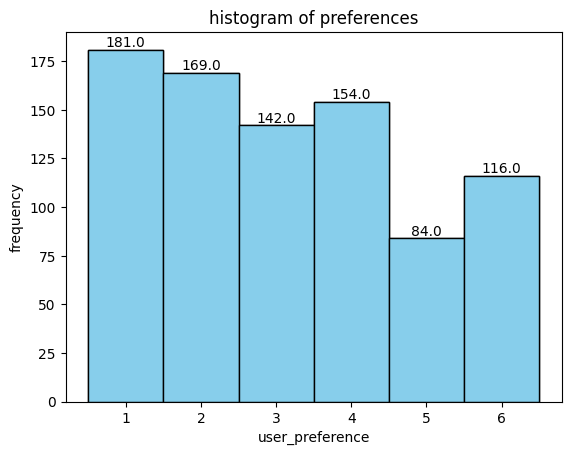

In [ ]:
bins = [0.5,1.5,2.5,3.5,4.5,5.5,6.5]
plt.hist(df['user_pref'],bins=bins,color='skyblue', edgecolor='black', align='mid')
plt.xlabel('user_preference')
plt.ylabel('frequency')
plt.title('histogram of preferences')
plt.xticks([1,2,3,4,5,6])
hist_vals, bin_edges, _ = plt.hist(df['user_pref'], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    plt.text(i+1, count, count, ha='center', va='bottom')
plt.show()

In [ ]:
df.loc[df['trip_purpose'] == 6, 'trip_purpose'] = 4

In [ ]:
df1=df[df['user_pref']==1]
df2=df[df['user_pref']==2]
df3=df[df['user_pref']==3]
df4=df[df['user_pref']==4]
df5=df[df['user_pref']==5]
df6=df[df['user_pref']==6]

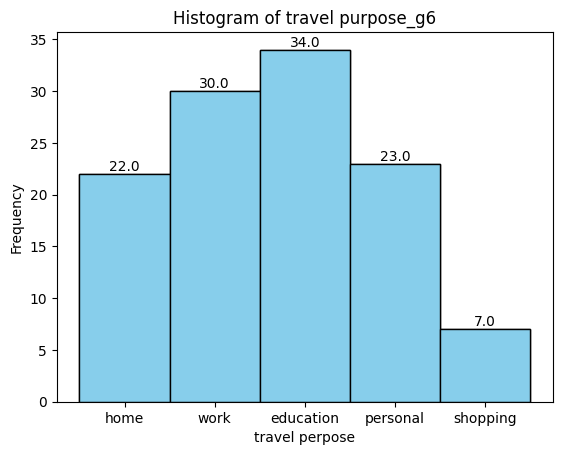

In [ ]:
bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
plt.hist(df6['trip_purpose'], bins=bins, color='skyblue', edgecolor='black', align='mid')
plt.xlabel('travel perpose')
plt.ylabel('Frequency')
plt.title('Histogram of travel purpose_g6')
labels = ['home', 'work', 'education', 'personal', 'shopping']
plt.xticks([1, 2, 3, 4, 5], labels)

hist_vals, _, _ = plt.hist(df6['trip_purpose'], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    plt.text(i + 1, count, count, ha='center', va='bottom')

plt.show()

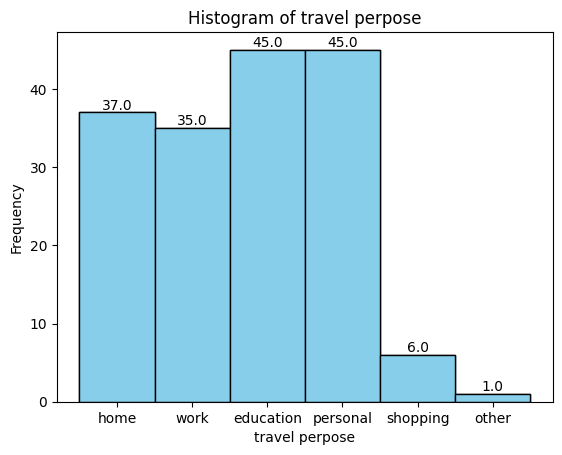

In [ ]:
bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5,6.5]
plt.hist(df2['trip_purpose'], bins=bins, color='skyblue', edgecolor='black', align='mid')
plt.xlabel('travel perpose')
plt.ylabel('Frequency')
plt.title('Histogram of travel perpose')
labels = ['home', 'work', 'education', 'personal', 'shopping','other']
plt.xticks([1, 2, 3, 4, 5,6], labels)

hist_vals, _, _ = plt.hist(df2['trip_purpose'], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    plt.text(i + 1, count, count, ha='center', va='bottom')

plt.show()

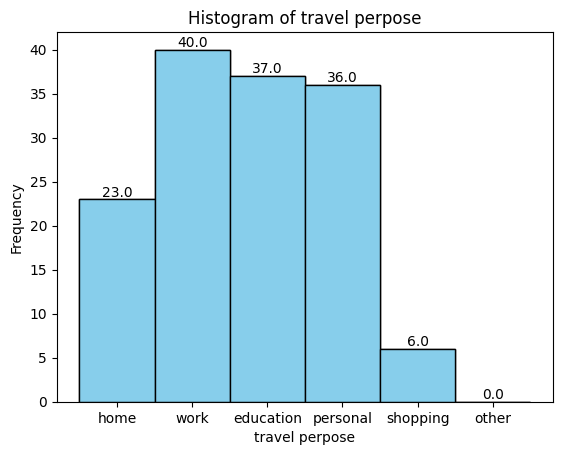

In [ ]:
bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5,6.5]
plt.hist(df3['trip_purpose'], bins=bins, color='skyblue', edgecolor='black', align='mid')
plt.xlabel('travel perpose')
plt.ylabel('Frequency')
plt.title('Histogram of travel perpose')
labels = ['home', 'work', 'education', 'personal', 'shopping','other']
plt.xticks([1, 2, 3, 4, 5,6], labels)

hist_vals, _, _ = plt.hist(df3['trip_purpose'], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    plt.text(i + 1, count, count, ha='center', va='bottom')

plt.show()

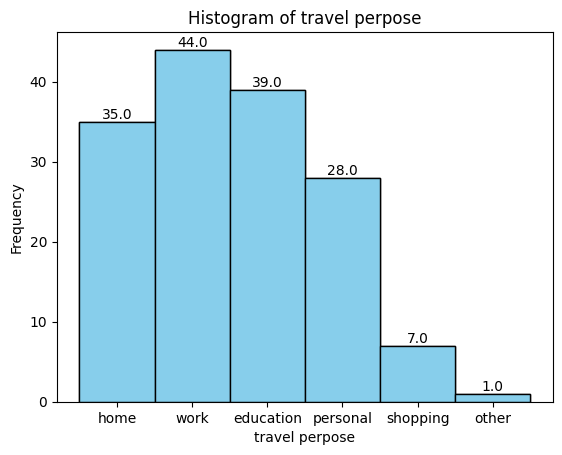

In [ ]:
bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5,6.5]
plt.hist(df4['trip_purpose'], bins=bins, color='skyblue', edgecolor='black', align='mid')
plt.xlabel('travel perpose')
plt.ylabel('Frequency')
plt.title('Histogram of travel perpose')
labels = ['home', 'work', 'education', 'personal', 'shopping','other']
plt.xticks([1, 2, 3, 4, 5,6], labels)

hist_vals, _, _ = plt.hist(df4['trip_purpose'], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    plt.text(i + 1, count, count, ha='center', va='bottom')

plt.show()

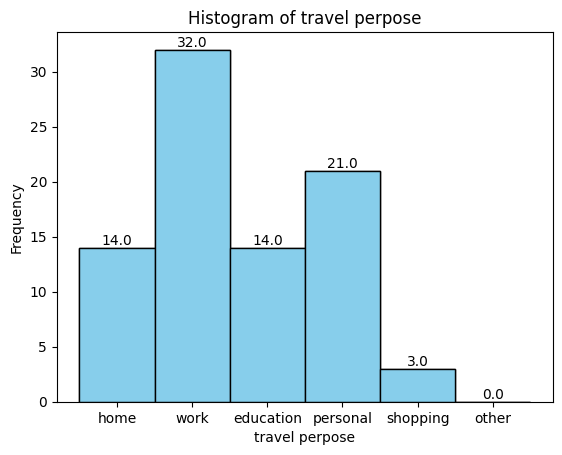

In [ ]:
bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5,6.5]
plt.hist(df5['trip_purpose'], bins=bins, color='skyblue', edgecolor='black', align='mid')
plt.xlabel('travel perpose')
plt.ylabel('Frequency')
plt.title('Histogram of travel perpose')
labels = ['home', 'work', 'education', 'personal', 'shopping','other']
plt.xticks([1, 2, 3, 4, 5,6], labels)

hist_vals, _, _ = plt.hist(df5['trip_purpose'], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    plt.text(i + 1, count, count, ha='center', va='bottom')

plt.show()

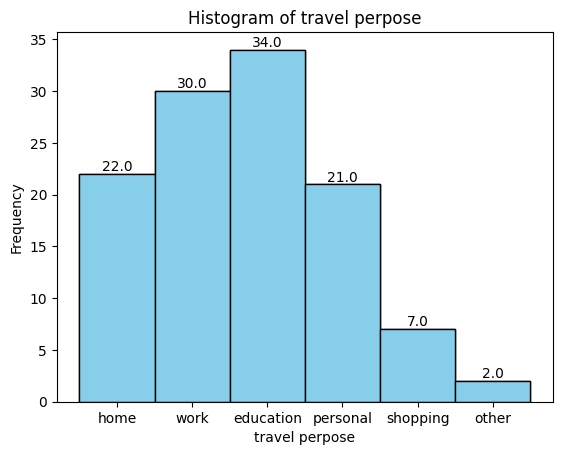

In [ ]:
bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5,6.5]
plt.hist(df6['trip_purpose'], bins=bins, color='skyblue', edgecolor='black', align='mid')
plt.xlabel('travel perpose')
plt.ylabel('Frequency')
plt.title('Histogram of travel perpose')
labels = ['home', 'work', 'education', 'personal', 'shopping','other']
plt.xticks([1, 2, 3, 4, 5,6], labels)

hist_vals, _, _ = plt.hist(df6['trip_purpose'], bins=bins, color='skyblue', edgecolor='black', align='mid')
for i, bin_val in enumerate(hist_vals):
    count = bin_val
    plt.text(i + 1, count, count, ha='center', va='bottom')

plt.show()